# LR-VMC sampling

Compare ground state sampling with tangent space reweighting.
We use a six site Holstein ring with one electron (polaron problem), at most five phonons in
total, and total momentum $k=0$. We use a simple coherent state ansatz.

Since the configuration space is small (462 configurations), everything is enumerated and sampled directly.


In [1]:
from itertools import combinations_with_replacement

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh
from scipy.optimize import minimize
from scipy.sparse import lil_matrix
from scipy.special import gammaln

# Model and experiment settings.
L, MAX_PHONONS = 6, 5
T, OMEGA, LAMBDA = 1.0, 1.0, 1.0
G = np.sqrt(2 * LAMBDA * OMEGA * T)  # lambda = g^2 / (2 omega t)
SAMPLE_SIZES = np.array([2000, 4000, 8000, 16000, 32000])
REPEATS, N_STATES, SEED = 100, 3, 123
OVERLAP_TOL = 1e-10

The Hamiltonian in a site basis is

$$
H=-t\sum_i(c^\dagger_{i+1}c_i+\mathrm{h.c.})
  +\omega\sum_i b_i^\dagger b_i-g\sum_i n_i(b_i^\dagger+b_i).
$$

We can describe phonon occupations relative to the electron. In the $k=0$ basis,
electron hopping shifts the entire phonon pattern by one site, the coupling
creates or destroys a phonon at relative site 0.


In [2]:
basis = np.array([
    np.bincount(sites, minlength=L)
    for n in range(MAX_PHONONS + 1)
    for sites in combinations_with_replacement(range(L), n)
])
lookup = {tuple(n): i for i, n in enumerate(basis)}
H = lil_matrix((len(basis), len(basis)))
for col, n in enumerate(basis):
    H[col, col] += OMEGA * n.sum()
    for shift in (-1, 1):
        H[lookup[tuple(np.roll(n, shift))], col] -= T
    if n.sum() < MAX_PHONONS:
        m = n.copy()
        m[0] += 1
        row = lookup[tuple(m)]
        H[row, col] = H[col, row] = -G * np.sqrt(m[0])
H = H.tocsr()
assert (H - H.T).nnz == 0
print(f"Hilbert-space dimension: {len(basis)}")

Hilbert-space dimension: 462


Optimize six positive coherent displacements $\alpha_j$ by deterministic
energy minimization in this truncated space:

$$
\psi_\alpha(n)=\mathcal N(\alpha)^{-1/2}
      \prod_j\frac{\alpha_j^{n_j}}{\sqrt{n_j!}},\qquad
\partial_{\alpha_j}\psi_\alpha(n)
      =\frac{n_j-\langle n_j\rangle_{|\psi|^2}}{\alpha_j}\psi_\alpha(n).
$$

The response states are $|\psi_0\rangle=|\psi\rangle$ and
$|\psi_{j+1}\rangle=\partial_{\alpha_j}|\psi\rangle$ for $j=0,\ldots,5$.
In the code, $\Phi_{n\mu}=\langle n|\psi_\mu\rangle$. The energies of the
Hamiltonian projected into this space serve as the reference for sampling error.


In [3]:
log_factorial = 0.5 * gammaln(basis + 1).sum(axis=1)


def state_and_tangent(alpha):
    psi = np.exp(basis @ np.log(alpha) - log_factorial)
    psi /= np.linalg.norm(psi)
    dpsi = psi[:, None] * (basis - psi**2 @ basis) / alpha
    return psi, dpsi


def objective(alpha):
    psi, dpsi = state_and_tangent(alpha)
    hpsi = H @ psi
    return psi @ hpsi, 2 * dpsi.T @ hpsi


fit = minimize(
    objective, np.full(L, G / (OMEGA * L)), jac=True,
    method="L-BFGS-B", bounds=[(1e-6, None)] * L,
    options={"ftol": 1e-12, "gtol": 1e-8, "maxiter": 1000, "maxls": 40},
)
assert fit.success, fit.message
psi, dpsi = state_and_tangent(fit.x)
Phi = np.column_stack((psi, dpsi))
HPhi = H @ Phi
S_exact, A_exact = Phi.T @ Phi, Phi.T @ HPhi
reference = eigh(A_exact, S_exact, eigvals_only=True)[:N_STATES]
print("Optimized displacements:", np.round(fit.x, 5))
print("Deterministic projected energies:", np.round(reference, 6))

Optimized displacements: [0.69204 0.24018 0.09078 0.05571 0.09078 0.24018]
Deterministic projected energies: [-2.935726 -1.926171 -1.228669]


For either normalized distribution, ground state (GS) or reweighted (RW),

$$
p_{\rm GS}(n)=|\langle n|\psi\rangle|^2,\qquad
p_{\rm RW}(n)=\frac{\sum_\mu|\langle n|\psi_\mu\rangle|^2}
                        {\sum_\mu\langle\psi_\mu|\psi_\mu\rangle},
$$

draw $N$ independent configurations and form

$$
\widehat S_{\mu\nu}=\frac1N\sum_{a=1}^N
  \frac{\langle\psi_\mu|n_a\rangle\langle n_a|\psi_\nu\rangle}{p(n_a)},\qquad
\widehat A_{\mu\nu}=\frac1N\sum_{a=1}^N
  \frac{\langle\psi_\mu|n_a\rangle\langle n_a|H|\psi_\nu\rangle}{p(n_a)}.
$$

These estimate $S_{\mu\nu}=\langle\psi_\mu|\psi_\nu\rangle$ and
$A_{\mu\nu}=\langle\psi_\mu|H|\psi_\nu\rangle$.
For these real states, solve $\tfrac12(\widehat A+\widehat A^T)c=E\widehat S c$ with the same
symmetrization for both methods. The matrix estimates are unbiased, but their
eigenvalues need not be.


Here is a rough estimate of the computational cost scaling:

Let $P$ be the parameter count and $C_\psi$ the cost of one
amplitude evaluation. Reverse AD obtains all $P$
derivatives with $O(C_\psi)$ work; differentiating
$\langle n|H|\psi\rangle$ therefore costs $O(C_\psi)$.
Both GS and reweighted LR have this derivative cost scaling.
Each sample adds two outer products, giving total work
$O(N[C_\psi+P^2])$ and $O(P^2)$ matrix storage, plus autodiff workspace.
Matrix free JVP/VJP contractions remove the outer products, giving
$O(N[C_\psi+P])$ work per matrix vector product without storing the matrices.


In [ ]:
probabilities = {"Ground-state sampling": psi**2,
                 "Reweighted": np.sum(Phi**2, axis=1)}
probabilities = {name: p / p.sum() for name, p in probabilities.items()}


def sampled_energies(p, counts):
    weights = counts / (counts.sum() * p)
    overlap = Phi.T @ (weights[:, None] * Phi)
    projected = Phi.T @ (weights[:, None] * HPhi)
    s = np.linalg.eigvalsh(overlap)
    if s[0] <= OVERLAP_TOL * s[-1]:
        return np.full(N_STATES, np.nan)
    return eigh((projected + projected.T) / 2, overlap,
                eigvals_only=True)[:N_STATES]


results = {}
streams = np.random.SeedSequence(SEED).spawn(len(probabilities))
for (name, p), stream in zip(probabilities.items(), streams):
    rng = np.random.default_rng(stream)
    results[name] = np.array([
        [sampled_energies(p, rng.multinomial(int(n), p))
         for _ in range(REPEATS)]
        for n in SAMPLE_SIZES
    ])

Ground-state sampling: failed draws at each sample size = [0 0 0 0 0]
Reweighted: failed draws at each sample size = [0 0 0 0 0]


Each point averages 100 independent calculations. Error bars are one standard error of that mean. Dashed lines are the deterministic energies of the same response space.


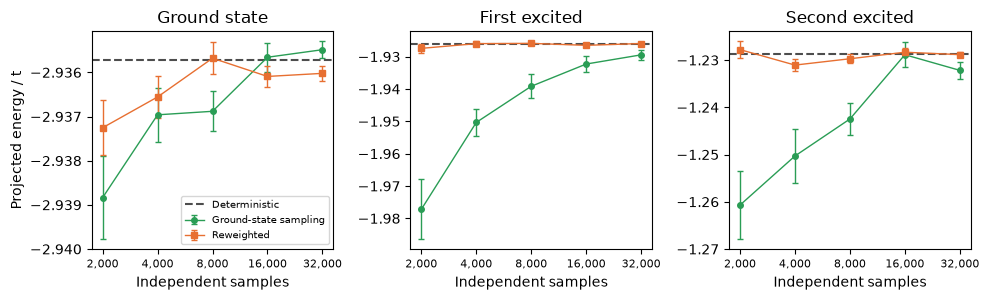

Ground-state sampling, RMSE at N=32000: [0.001921 0.015205 0.018331]
Reweighted, RMSE at N=32000: [0.001686 0.002896 0.004696]


In [5]:
fig, axes = plt.subplots(1, N_STATES, figsize=(10, 3.1), squeeze=False)
styles = [("#2a9d55", "o"), ("#e76f31", "s")]
for state, ax in enumerate(axes[0]):
    ax.axhline(reference[state], color="0.3", ls="--", label="Deterministic")
    for (name, samples), (color, marker) in zip(results.items(), styles):
        mean = samples[:, :, state].mean(axis=1)
        sem = samples[:, :, state].std(axis=1, ddof=1) / np.sqrt(REPEATS)
        ax.errorbar(SAMPLE_SIZES, mean, yerr=sem, color=color, marker=marker,
                    ms=4, capsize=2, lw=1, label=name)
    ax.set(xscale="log", xlabel="Independent samples",
           title=["Ground state", "First excited", "Second excited"][state])
    ax.set_xticks(SAMPLE_SIZES, [f"{n:,}" for n in SAMPLE_SIZES], fontsize=8)
    ax.minorticks_off()
    ax.ticklabel_format(axis="y", useOffset=False)
axes[0, 0].set_ylabel("Projected energy / t")
axes[0, 0].legend(fontsize=7)
fig.tight_layout()
plt.show()

for name, samples in results.items():
    rmse = np.sqrt(np.mean((samples - reference)**2, axis=1))
    print(f"{name}, RMSE at N={SAMPLE_SIZES[-1]}: {rmse[-1].round(6)}")

Phonons away from the electron have small probability in the optimized coherent state, but
can contribute strongly to its derivatives through $n_j/\alpha_j$. Reweighting
samples these configurations more often.


## NQS experiment

Now use nn_eph for the wavefunction and continuous-time Monte Carlo (CTMC) sampling.
This is the same Hamiltonian and cutoff, expressed in momentum space. A walker is
$(k_e,n_q)$ with $k_e+\sum_q qn_q=0\pmod L$.

A one hidden layer ReLU network supplies a real log amplitude,
the phase network has no parameters.

$$
\psi_\theta(k_e,n_q)=
\frac{\exp[f_\theta(\mathrm{onehot}(k_e),n_q)]}{\sqrt{\prod_q n_q!}}.
$$

Training uses the sampled VMC gradient and AMSGrad. We
regularize each sampled overlap matrix and average 100 independent chains.
We choose 20 hidden neurons and $k=0$.


In [ ]:
import sys
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

repo = Path.cwd() if (Path.cwd() / "nn_eph").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo))
from nn_eph import config
config.setup_jax()
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import optax
from nn_eph import hamiltonians, lattices, models, samplers, wavefunctions

# Neural state and Monte Carlo settings
NN_WIDTH, NN_SEED = 20, 12
NN_STEPS, NN_RATE = 500, 0.01
NN_TRAIN_SAMPLES, NN_EQUIL = 2000, 500
NN_SAMPLE_SIZES = np.array([500, 1000, 2000, 4000, 8000])
NN_REPEATS, NN_METRIC_CUTOFF = 100, 1e-6
NN_CONCURRENT_CHAINS = 4

nn_lattice = lattices.one_dimensional_chain(L)
dispersion = -2 * T * np.cos(2 * np.pi * np.arange(L) / L)
nn_ham = hamiltonians.kq(
    (OMEGA,) * L, tuple(dispersion),
    tuple((G / np.sqrt(L),) * L for _ in range(L)), MAX_PHONONS,
)
nn_model = models.MLP([NN_WIDTH, 1], activation=jax.nn.relu, param_dtype=jnp.float64)
zero_phase = models.MLP([0], kernel_init=jax.nn.initializers.zeros,
                        param_dtype=jnp.float64)
nn_parameters = [
    nn_model.init(jax.random.PRNGKey(NN_SEED), jnp.zeros(2 * L)),
    zero_phase.init(jax.random.PRNGKey(NN_SEED + 1), jnp.zeros(2 * L)),
]
nn_wave = wavefunctions.nn_complex(
    nn_model.apply, zero_phase.apply,
    sum(x.size for x in jax.tree.leaves(nn_parameters)),
    mask=(1.0, 0.0), get_input=wavefunctions.get_input_k,
)
nn_walker = [(0,), jnp.zeros(L, dtype=int)]  # Vacuum: total momentum zero.


def mc_random_numbers(key, n_samples):
    key, warm_key, sample_key = jax.random.split(key, 3)
    return (key, jax.random.uniform(warm_key, (NN_EQUIL,)),
            jax.random.uniform(sample_key, (int(n_samples),)))


print(f"NN trainable parameters: {nn_wave.n_parameters}")

NN trainable parameters: 281


The sampled gradient is
$\nabla_\theta E=2(\langle E_L\nabla_\theta\log\psi\rangle
-\langle E_L\rangle\langle\nabla_\theta\log\psi\rangle)$.
Each iteration starts a fresh chain from the vacuum, equilibrates it, and
then samples using an independent random stream. We retain the final
parameters. The training trace is noisy and is not a convergence certificate.


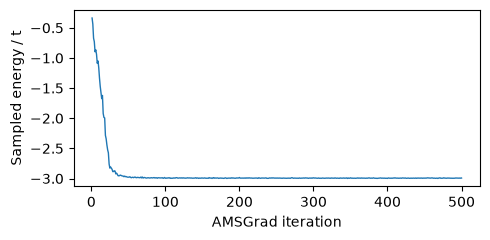

In [7]:
train_sampler = samplers.continuous_time(NN_EQUIL, NN_TRAIN_SAMPLES,
                                        green_reweight=False)
optimizer = optax.amsgrad(NN_RATE)
optimizer_state = optimizer.init(nn_wave.serialize(nn_parameters))
train_key = jax.random.PRNGKey(NN_SEED + 22)
nn_training_energy = []
for iteration in range(NN_STEPS):
    train_key, warm, draws = mc_random_numbers(train_key, NN_TRAIN_SAMPLES)
    out = train_sampler.sampling(
        nn_walker, nn_ham, nn_parameters, nn_wave, nn_lattice, draws,
        dev_thresh_fac=jnp.inf, equilibration_random_numbers=warm,
    )
    gradient = 2 * (out[3] - out[1] * out[2])
    updates, optimizer_state = optimizer.update(gradient, optimizer_state)
    nn_parameters = nn_wave.update_parameters(nn_parameters.copy(), updates)
    nn_training_energy.append(float(out[1]))

plt.figure(figsize=(5, 2.5))
plt.plot(np.arange(1, NN_STEPS + 1), nn_training_energy, lw=1)
plt.xlabel("AMSGrad iteration")
plt.ylabel("Sampled energy / t")
plt.tight_layout()
plt.show()

Build the deterministic reference in this momentum basis. NN derivatives
contain redundant directions (including overall normalization). For each
exact or sampled matrix pair, diagonalize $S$ and retain its eigenvectors
with $s_i/s_{\max}>10^{-6}$ (`NN_METRIC_CUTOFF`) before solving for energies.


In [8]:
electron_k = (-basis @ np.arange(L)) % L  # Here the columns of basis label q.
H_k = lil_matrix(H.shape)
for col, n in enumerate(basis):
    H_k[col, col] = OMEGA * n.sum() + dispersion[electron_k[col]]
    if n.sum() < MAX_PHONONS:
        for q in range(L):
            m = n.copy()
            m[q] += 1
            row = lookup[tuple(m)]
            H_k[row, col] = H_k[col, row] = -G / np.sqrt(L) * np.sqrt(m[q])
H_k = H_k.tocsr()
# The site and momentum representations must have the same full spectrum.
np.testing.assert_allclose(eigh(H_k.toarray(), eigvals_only=True),
                           eigh(H.toarray(), eigvals_only=True), atol=1e-12)

nn_logs = np.asarray(jax.vmap(lambda k, n: nn_wave.calc_overlap(
    (k,), n, nn_parameters, nn_lattice))(jnp.array(electron_k), jnp.array(basis)))
nn_gradients = np.asarray(jax.vmap(lambda k, n: nn_wave.calc_overlap_gradient(
    (k,), n, nn_parameters, nn_lattice))(jnp.array(electron_k), jnp.array(basis)))
nn_psi = np.exp(nn_logs.real - log_factorial)
nn_psi /= np.linalg.norm(nn_psi)
nn_Phi = nn_psi[:, None] * np.column_stack((np.ones(len(basis)), nn_gradients.real))
nn_S = nn_Phi.T @ nn_Phi
nn_A = nn_Phi.T @ (H_k @ nn_Phi)


def nn_response_energies(matrix, metric):
    matrix, metric = (matrix + matrix.T) / 2, (metric + metric.T) / 2
    s, u = eigh(metric)
    keep = s > NN_METRIC_CUTOFF * s[-1]
    rank = int(keep.sum())
    if rank < N_STATES:
        return np.full(N_STATES, np.nan), rank
    transform = u[:, keep] / np.sqrt(s[keep])
    return eigh(transform.T @ matrix @ transform, eigvals_only=True)[:N_STATES], rank


nn_reference, nn_exact_rank = nn_response_energies(nn_A, nn_S)
print("Deterministic retained response dimension:", nn_exact_rank)
print("Final NN energy (deterministic):", round(nn_psi @ (H_k @ nn_psi), 6))
print("Deterministic NN response energies:", nn_reference.round(6))

Deterministic retained response dimension: 129
Final NN energy (deterministic): -2.994053
Deterministic NN response energies: [-2.995759 -1.975336 -1.779784]


Compare independently seeded CTMC chains with `green_reweight=False/True`.


In [9]:
nn_results, nn_ranks = {}, {}
lr_key = jax.random.PRNGKey(NN_SEED + 1000)
for name, reweight in [("Ground-state sampling", False), ("Reweighted", True)]:
    samples_by_size, ranks_by_size = [], []
    for n_samples in NN_SAMPLE_SIZES:
        lr_sampler = samplers.continuous_time(NN_EQUIL, int(n_samples),
                                             green_reweight=reweight)
        random_pairs = []
        for repeat in range(NN_REPEATS):
            lr_key, warm, draws = mc_random_numbers(lr_key, n_samples)
            random_pairs.append((warm, draws))

        def sample_chain(random_pair):
            warm, draws = random_pair
            out = lr_sampler.sampling_lr(
                nn_walker, nn_ham, nn_parameters, nn_wave, nn_lattice, draws,
                dev_thresh_fac=jnp.inf, equilibration_random_numbers=warm,
            )
            return nn_response_energies(np.asarray(out[6]).real,
                                         np.asarray(out[5]).real)

        with ThreadPoolExecutor(max_workers=NN_CONCURRENT_CHAINS) as pool:
            samples, ranks = zip(*pool.map(sample_chain, random_pairs))
        samples_by_size.append(samples)
        ranks_by_size.append(ranks)
        print(f"{name}, N={n_samples}: retained rank {min(ranks)}–{max(ranks)}", flush=True)
    nn_results[name] = np.array(samples_by_size)
    nn_ranks[name] = np.array(ranks_by_size)
    failed = np.isnan(nn_results[name][:, :, 0]).sum(axis=1)
    print(f"{name}: failed chains at each sample size = {failed}")

Ground-state sampling, N=500: retained rank 46–86


Ground-state sampling, N=1000: retained rank 63–98


Ground-state sampling, N=2000: retained rank 85–115


Ground-state sampling, N=4000: retained rank 101–127


Ground-state sampling, N=8000: retained rank 113–129


...

Reweighted, N=1000: retained rank 84–120


Reweighted, N=2000: retained rank 105–129


Reweighted, N=4000: retained rank 112–132


Reweighted, N=8000: retained rank 121–131


Reweighted: failed chains at each sample size = [0 0 0 0 0]


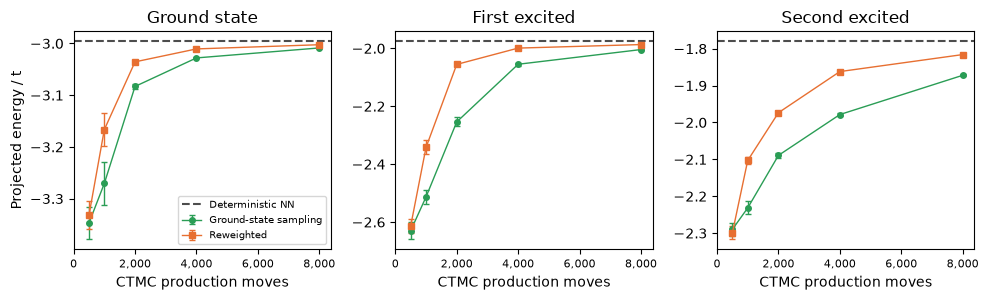

Ground-state sampling, RMSE at N=8000: [0.013277 0.037793 0.096436]
Reweighted, RMSE at N=8000: [0.00682  0.012117 0.037306]


In [10]:
fig, axes = plt.subplots(1, N_STATES, figsize=(10, 3.1), squeeze=False)
for state, ax in enumerate(axes[0]):
    ax.axhline(nn_reference[state], color="0.3", ls="--", label="Deterministic NN")
    for (name, samples), (color, marker) in zip(nn_results.items(), styles):
        mean = samples[:, :, state].mean(axis=1)
        sem = samples[:, :, state].std(axis=1, ddof=1) / np.sqrt(NN_REPEATS)
        ax.errorbar(NN_SAMPLE_SIZES, mean, yerr=sem, color=color, marker=marker,
                    ms=4, capsize=2, lw=1, label=name)
    ax.set(xlabel="CTMC production moves",
           title=["Ground state", "First excited", "Second excited"][state])
    ticks = [0, 2000, 4000, 6000, 8000]
    ax.set_xticks(ticks, [f"{n:,}" for n in ticks], fontsize=8)
    ax.minorticks_off()
    ax.ticklabel_format(axis="y", useOffset=False)
axes[0, 0].set_ylabel("Projected energy / t")
axes[0, 0].legend(fontsize=7)
fig.tight_layout()
plt.show()

for name, samples in nn_results.items():
    rmse = np.sqrt(np.mean((samples[-1] - nn_reference)**2, axis=0))
    print(f"{name}, RMSE at N={NN_SAMPLE_SIZES[-1]}: {rmse.round(6)}")